# 05 — Walk-forward results (visualization)

Loads `models/walkforward_gbm/` artifacts (backtest). Optionally overlays the latest
**forward** operational score from `models/score/` (after `make score`).

```bash
make pipeline          # walk-forward backtest
make score-no-download # forward forecast: next Tuesday after latest USDA data
```

Val/test slices are derived from saved walk-forward predictions. The red point is the
operational one-ahead forecast (e.g. data through 18-Aug → predict 25-Aug).

In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from freight_rates.artifacts import require_walkforward_artifacts, val_test_headlines
from freight_rates.evaluation import format_dual_regime_report

ROOT = Path("..").resolve()
wf = require_walkforward_artifacts(ROOT / "models")
preds = wf.predictions
by_week = wf.by_week
by_history = wf.by_history
overall = wf.overall

SCORE_DIR = ROOT / "models" / "score"
score_preds = None
score_meta = None
latest_score_path = SCORE_DIR / "latest_predictions.parquet"
if latest_score_path.exists():
    score_preds = pd.read_parquet(latest_score_path)
    score_preds["date"] = pd.to_datetime(score_preds["date"])
    meta_path = SCORE_DIR / "latest.json"
    if meta_path.exists():
        score_meta = json.loads(meta_path.read_text())
    forecast_date = score_meta["forecast_date"] if score_meta else str(score_preds["date"].max().date())
    last_observed = score_meta.get("last_observed_date") if score_meta else None
    msg = f"Latest operational score: {forecast_date} ({len(score_preds):,} lanes)"
    if last_observed:
        msg += f"  |  last observed USDA week: {last_observed}"
    print(msg)
else:
    print("No operational score yet — run: make score-no-download")

windows = val_test_headlines(preds)
print(format_dual_regime_report(wf.dual_regime))
display(windows)
display(by_history)

Latest operational score: 2026-08-25 (73 lanes)  |  last observed USDA week: 2026-08-18
=== Dual-regime headline [full] ===
overall: n=5,689  MAE=0.1402  lag1=0.1393  lift=-0.0009  beats_lag1=False
cold 0-4: n=246  MAE=0.3896  lag1=0.4068  lift=+0.0171  beats_lag1=True


,label,n,mae,mae_baseline,mae_lift,beats_lag1_overall,cold_n,cold_mae,cold_mae_baseline,cold_mae_lift,beats_lag1_cold,window
0,val,1997,0.073159,0.073906,0.000747,True,88,0.162400,0.197574,0.035174,True,val
1,test,3692,0.176464,0.174646,-0.001817,False,158,0.516205,0.523295,0.007090,True,test
2,full,5689,0.140201,0.139284,-0.000917,False,246,0.389641,0.406777,0.017136,True,full


,history_bucket,n,mae,medae,mape,mae_baseline,medae_baseline,mae_lift
0,0-4,246,0.389641,0.138543,11.795310,0.406777,0.188696,0.017136
1,5-19,593,0.189059,0.055031,5.410025,0.186153,0.052632,-0.002906
2,20-99,4613,0.122105,0.004659,3.580066,0.120386,0.000000,-0.001718
3,100+,237,0.111261,0.056391,3.079787,0.112180,0.062016,0.000919


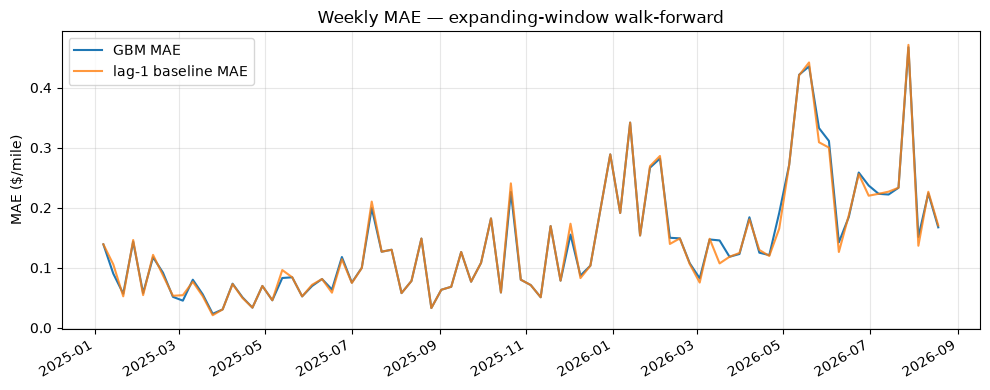

scored rows: 5,689


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_week["date"], by_week["mae"], label="GBM MAE")
if "mae_baseline" in by_week.columns:
    ax.plot(by_week["date"], by_week["mae_baseline"], label="lag-1 baseline MAE", alpha=0.8)
ax.set_title("Weekly MAE — expanding-window walk-forward")
ax.set_ylabel("MAE ($/mile)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
print(f"scored rows: {len(preds):,}")

Last Actual:  2026-08-18  rpm=4.1551  (n=73 lanes)
Last GBM est: 2026-08-25  rpm=4.1408  (n=73 lanes, forward forecast)
One-ahead OK: GBM is 1 week(s) after last Actual


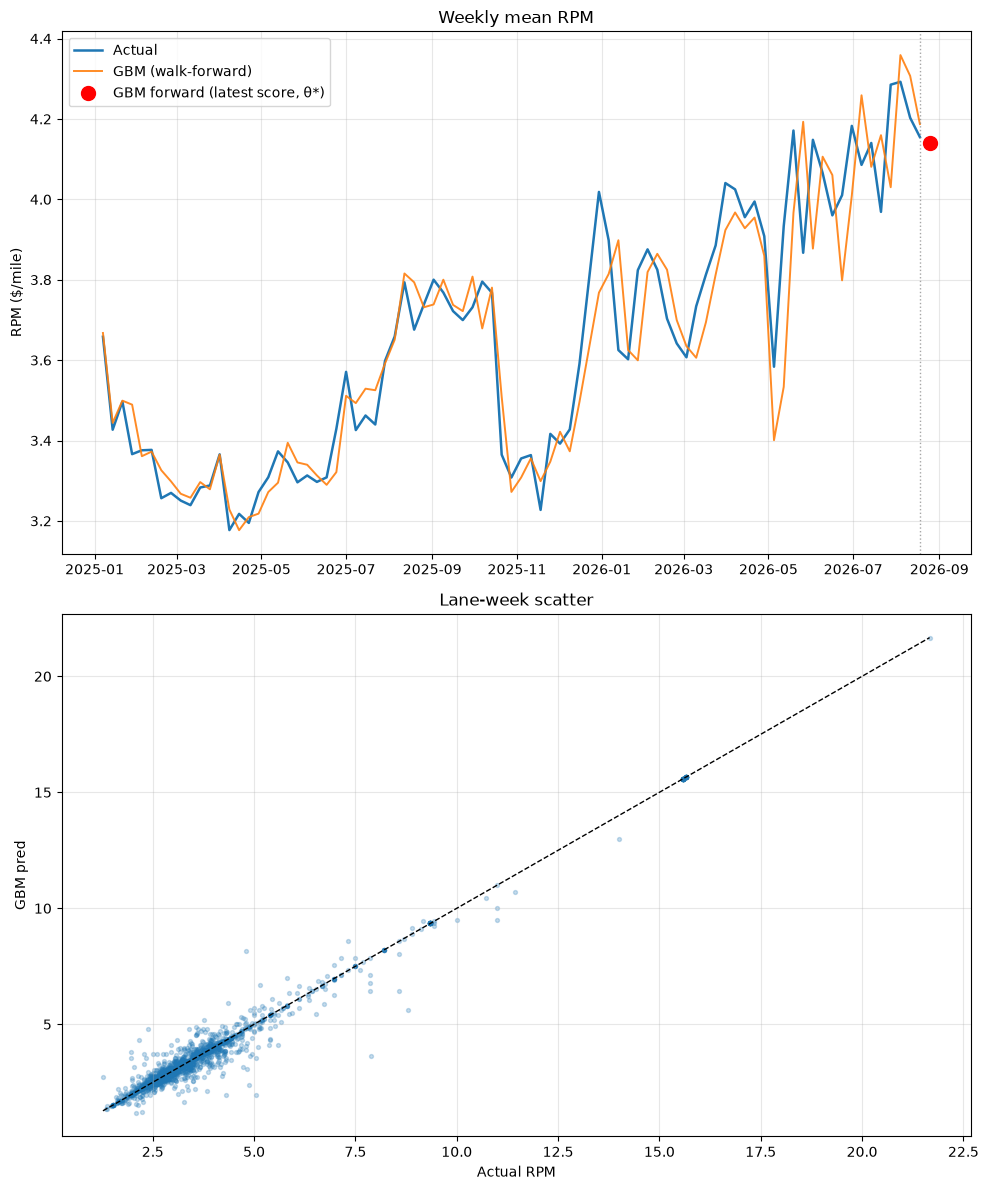

In [7]:
weekly_levels = (
    preds.groupby("date", as_index=False)
    .agg(
        rpm_true=("y_true", "mean"),
        rpm_gbm=("y_pred", "mean"),
        rpm_lag1=("y_pred_baseline", "mean"),
        n=("y_true", "size"),
    )
    .sort_values("date")
)

# One-ahead check: last published USDA week vs forward GBM forecast
if score_preds is not None:
    score_date = score_preds["date"].max()
    last_actual_row = weekly_levels.iloc[-1]
    score_gbm_mean = float(score_preds["y_pred"].mean())
    n_lanes = len(score_preds)
    print(
        f"Last Actual:  {last_actual_row['date'].date()}  "
        f"rpm={last_actual_row['rpm_true']:.4f}  (n={int(last_actual_row['n'])} lanes)"
    )
    print(
        f"Last GBM est: {score_date.date()}  "
        f"rpm={score_gbm_mean:.4f}  (n={n_lanes} lanes, forward forecast)"
    )
    weeks_ahead = (score_date - last_actual_row["date"]).days // 7
    print(f"One-ahead OK: GBM is {weeks_ahead} week(s) after last Actual")
else:
    last_row = weekly_levels.iloc[-1]
    print(f"Last Actual:  {last_row['date'].date()}  rpm={last_row['rpm_true']:.4f}")
    print(f"Last GBM est: {last_row['date'].date()}  rpm={last_row['rpm_gbm']:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 12))
axes[0].plot(weekly_levels["date"], weekly_levels["rpm_true"], label="Actual", lw=1.8)
axes[0].plot(weekly_levels["date"], weekly_levels["rpm_gbm"], label="GBM (walk-forward)", lw=1.4, alpha=0.9)
if score_preds is not None:
    score_week = (
        score_preds.groupby("date", as_index=False)
        .agg(rpm_gbm=("y_pred", "mean"))
        .sort_values("date")
    )
    axes[0].plot(
        score_week["date"],
        score_week["rpm_gbm"],
        color="red",
        marker="o",
        ms=10,
        lw=0,
        label="GBM forward (latest score, θ*)",
        zorder=5,
    )
    # vertical line at last observed actual
    last_actual_date = weekly_levels["date"].max()
    axes[0].axvline(last_actual_date, color="gray", ls=":", lw=1, alpha=0.7)
axes[0].set_title("Weekly mean RPM")
axes[0].set_ylabel("RPM ($/mile)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

scatter = preds.sample(n=min(2500, len(preds)), random_state=42)
axes[1].scatter(scatter["y_true"], scatter["y_pred"], s=8, alpha=0.25)
lims = [scatter["y_true"].min(), scatter["y_true"].max()]
axes[1].plot(lims, lims, color="black", lw=1, ls="--")
axes[1].set_xlabel("Actual RPM")
axes[1].set_ylabel("GBM pred")
axes[1].set_title("Lane-week scatter")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

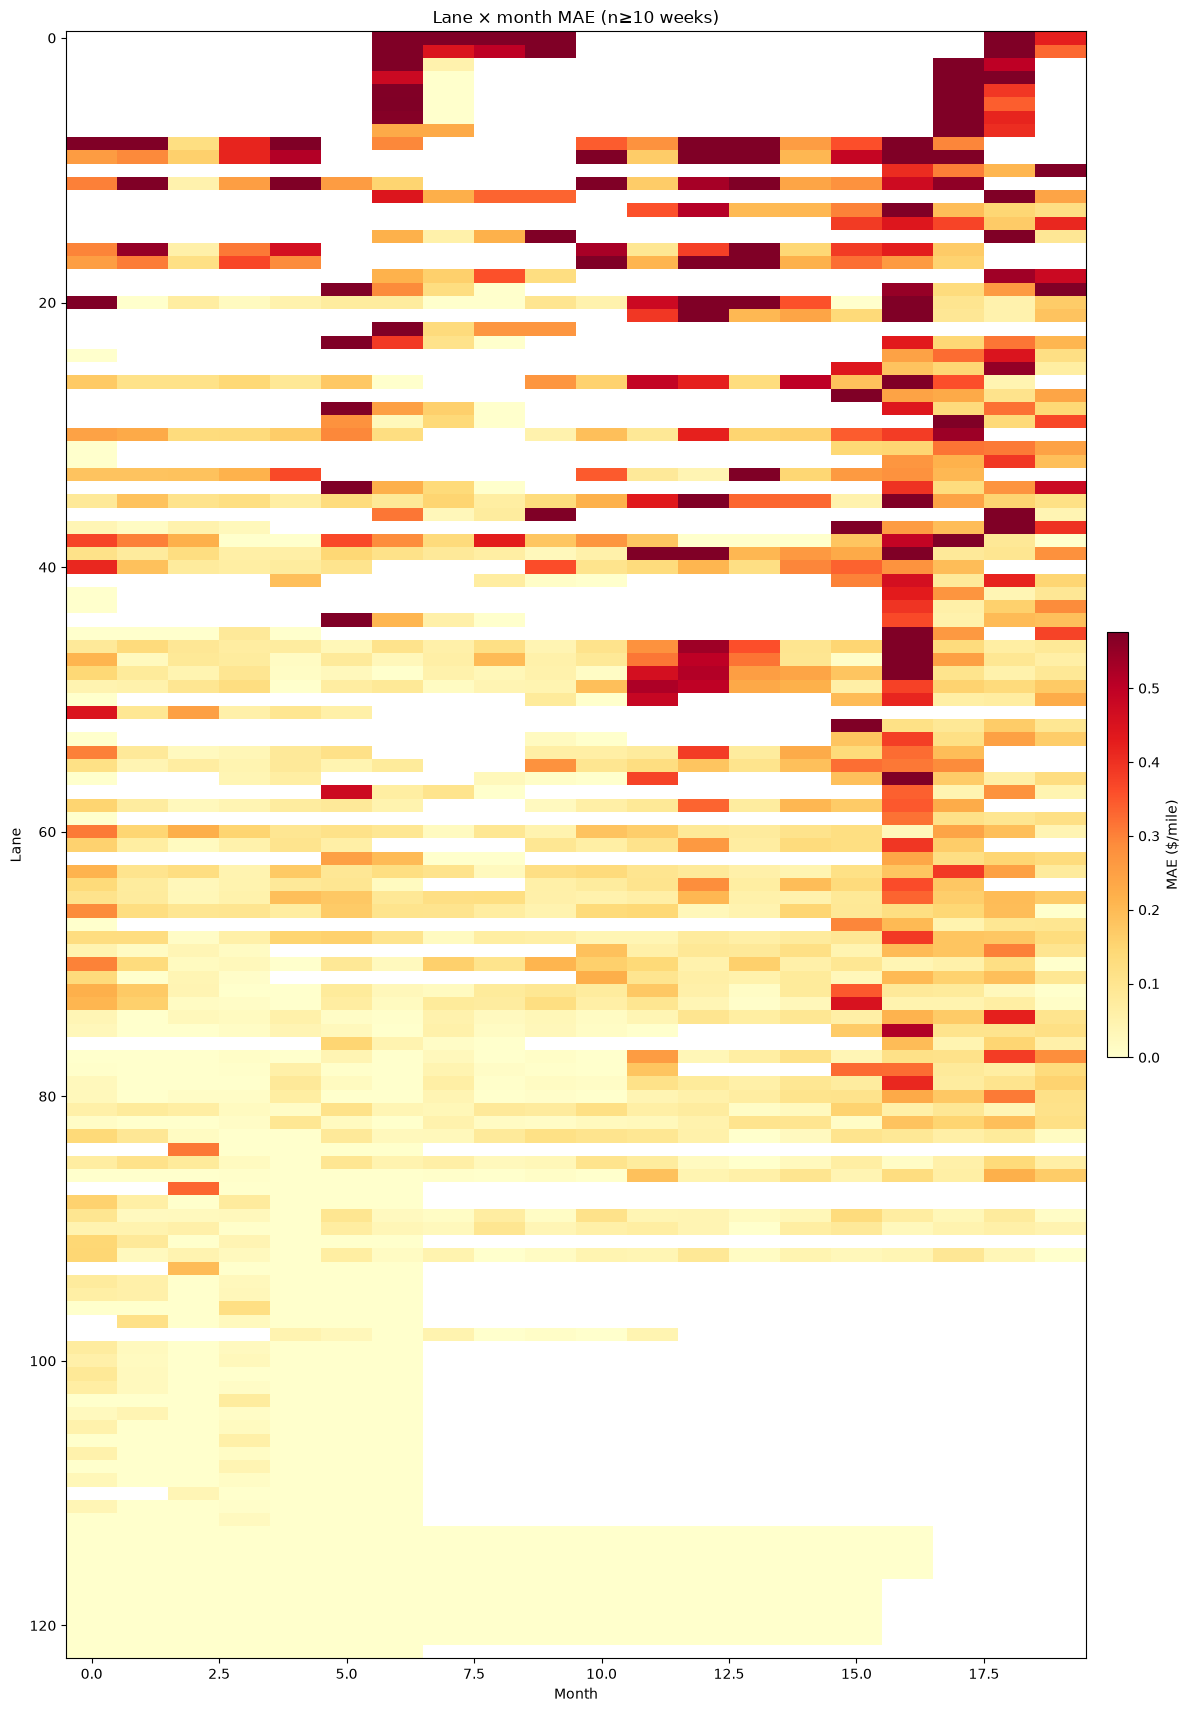

,lane_id,mae,n
0,"DELAWARE, MARYLAND AND EASTERN SHORE VIRGINIA ...",1.079530,16
1,"DELAWARE, MARYLAND AND EASTERN SHORE VIRGINIA ...",0.753637,16
2,GEORGIA -> PHILADELPHIA,0.743462,10
3,GEORGIA -> NEW YORK,0.714563,10
4,GEORGIA -> BALTIMORE,0.670547,10
5,GEORGIA -> CHICAGO,0.584371,10
6,GEORGIA -> ATLANTA,0.583939,10
7,GEORGIA -> BOSTON,0.551645,10
8,CENTRAL AND SOUTH FLORIDA -> ATLANTA,0.517394,51
9,CENTRAL AND SOUTH FLORIDA -> NEW YORK,0.489017,50


In [8]:
err = preds.copy()
err["date"] = pd.to_datetime(err["date"])
err["abs_err"] = (err["y_true"] - err["y_pred"]).abs()
err["month"] = err["date"].dt.to_period("M").astype(str)

lane_mae = (
    err.groupby("lane_id", as_index=False)
    .agg(mae=("abs_err", "mean"), n=("abs_err", "size"))
    .sort_values(["mae", "n"], ascending=[False, False])
)
MIN_WEEKS = 10
lane_mae_stable = lane_mae.loc[lane_mae["n"] >= MIN_WEEKS].reset_index(drop=True)

month_pivot = (
    err.groupby(["lane_id", "month"])["abs_err"]
    .mean()
    .unstack("month")
    .reindex(index=lane_mae_stable["lane_id"], columns=sorted(err["month"].unique()))
)

fig, ax = plt.subplots(figsize=(12, max(8, 0.14 * len(month_pivot))))
vmax = float(np.nanpercentile(month_pivot.to_numpy(dtype=float), 95))
im = ax.imshow(month_pivot.to_numpy(dtype=float), aspect="auto", cmap="YlOrRd", vmin=0, vmax=vmax)
ax.set_title(f"Lane × month MAE (n≥{MIN_WEEKS} weeks)")
ax.set_xlabel("Month")
ax.set_ylabel("Lane")
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label="MAE ($/mile)")
plt.tight_layout()
plt.show()
display(lane_mae_stable.head(15))